BITS ID: 2025AG05481

Name: JESWIN SANTOSH

Email: 2025ag05481@wilp.bits-pilani.ac.in

Date: 20-04-2026

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

import torch

# PART 1: DATASET LOADING AND EXPLORATION

In [2]:
df = pd.read_csv('AAPL_cleaned_data.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame
print("\n\nDataFrame Info:")
df.info()

# Display descriptive statistics
print("\n\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,Date,Adj_Close,Open,High,Low,Volume
0,2016-04-26,23.633232,23.533582,23.848390,23.533582,224064800
1,2016-04-27,22.154318,21.742124,22.355885,21.669650,458408400
2,2016-04-28,21.477142,22.106758,22.167907,21.345783,328970800
3,2016-04-29,21.230282,21.286902,21.452233,20.951712,274126000
4,2016-05-02,21.207630,21.282369,21.307282,20.926795,192640400




DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2513 non-null   object 
 1   Adj_Close  2513 non-null   float64
 2   Open       2513 non-null   float64
 3   High       2513 non-null   float64
 4   Low        2513 non-null   float64
 5   Volume     2513 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 117.9+ KB


Descriptive Statistics:


,Adj_Close,Open,High,Low,Volume
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,121.505833,121.400128,122.717567,120.180174,9.786799e+07
std,75.636638,75.581632,76.369431,74.842068,5.594671e+07
min,20.584820,20.507345,20.887870,20.386583,1.791060e+07
25%,44.371937,44.336547,44.678980,44.048847,5.849910e+07
50%,127.571976,127.627784,128.852131,126.090056,8.599280e+07
75%,177.260406,177.232738,178.592965,175.256046,1.188268e+08
max,285.922455,285.932471,288.350192,283.035157,4.584084e+08


In [3]:
# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Display data types after conversion
print("\nDataFrame Info after Date conversion:")
df.info()


DataFrame Info after Date conversion:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-04-26 to 2026-04-23
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj_Close  2513 non-null   float64
 1   Open       2513 non-null   float64
 2   High       2513 non-null   float64
 3   Low        2513 non-null   float64
 4   Volume     2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


# 1.1 Dataset Selection and Loading

In [4]:
dataset_name = "Apple Stock Prices (Last 10 years)"
dataset_source = "Yahoo Finance"
n_samples = df.shape[0]
n_features = df.shape[1]
sequence_length = 30
prediction_horizon = 5
problem_type = "Time Series Forecasting"

# Primary metric selection
primary_metric = "RMSE"
metric_justification = "For stock price prediction, Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) are commonly used as primary metrics. RMSE penalizes larger errors more, which is crucial in financial forecasting where large prediction errors can lead to significant financial losses."

print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Apple Stock Prices (Last 10 years)
Source: Yahoo Finance
Total Samples: 2513
Number of Features: 5
Sequence Length: 30
Prediction Horizon: 5
Primary Metric: RMSE
Metric Justification: For stock price prediction, Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) are commonly used as primary metrics. RMSE penalizes larger errors more, which is crucial in financial forecasting where large prediction errors can lead to significant financial losses.


# 1.2 Time Series Exploration

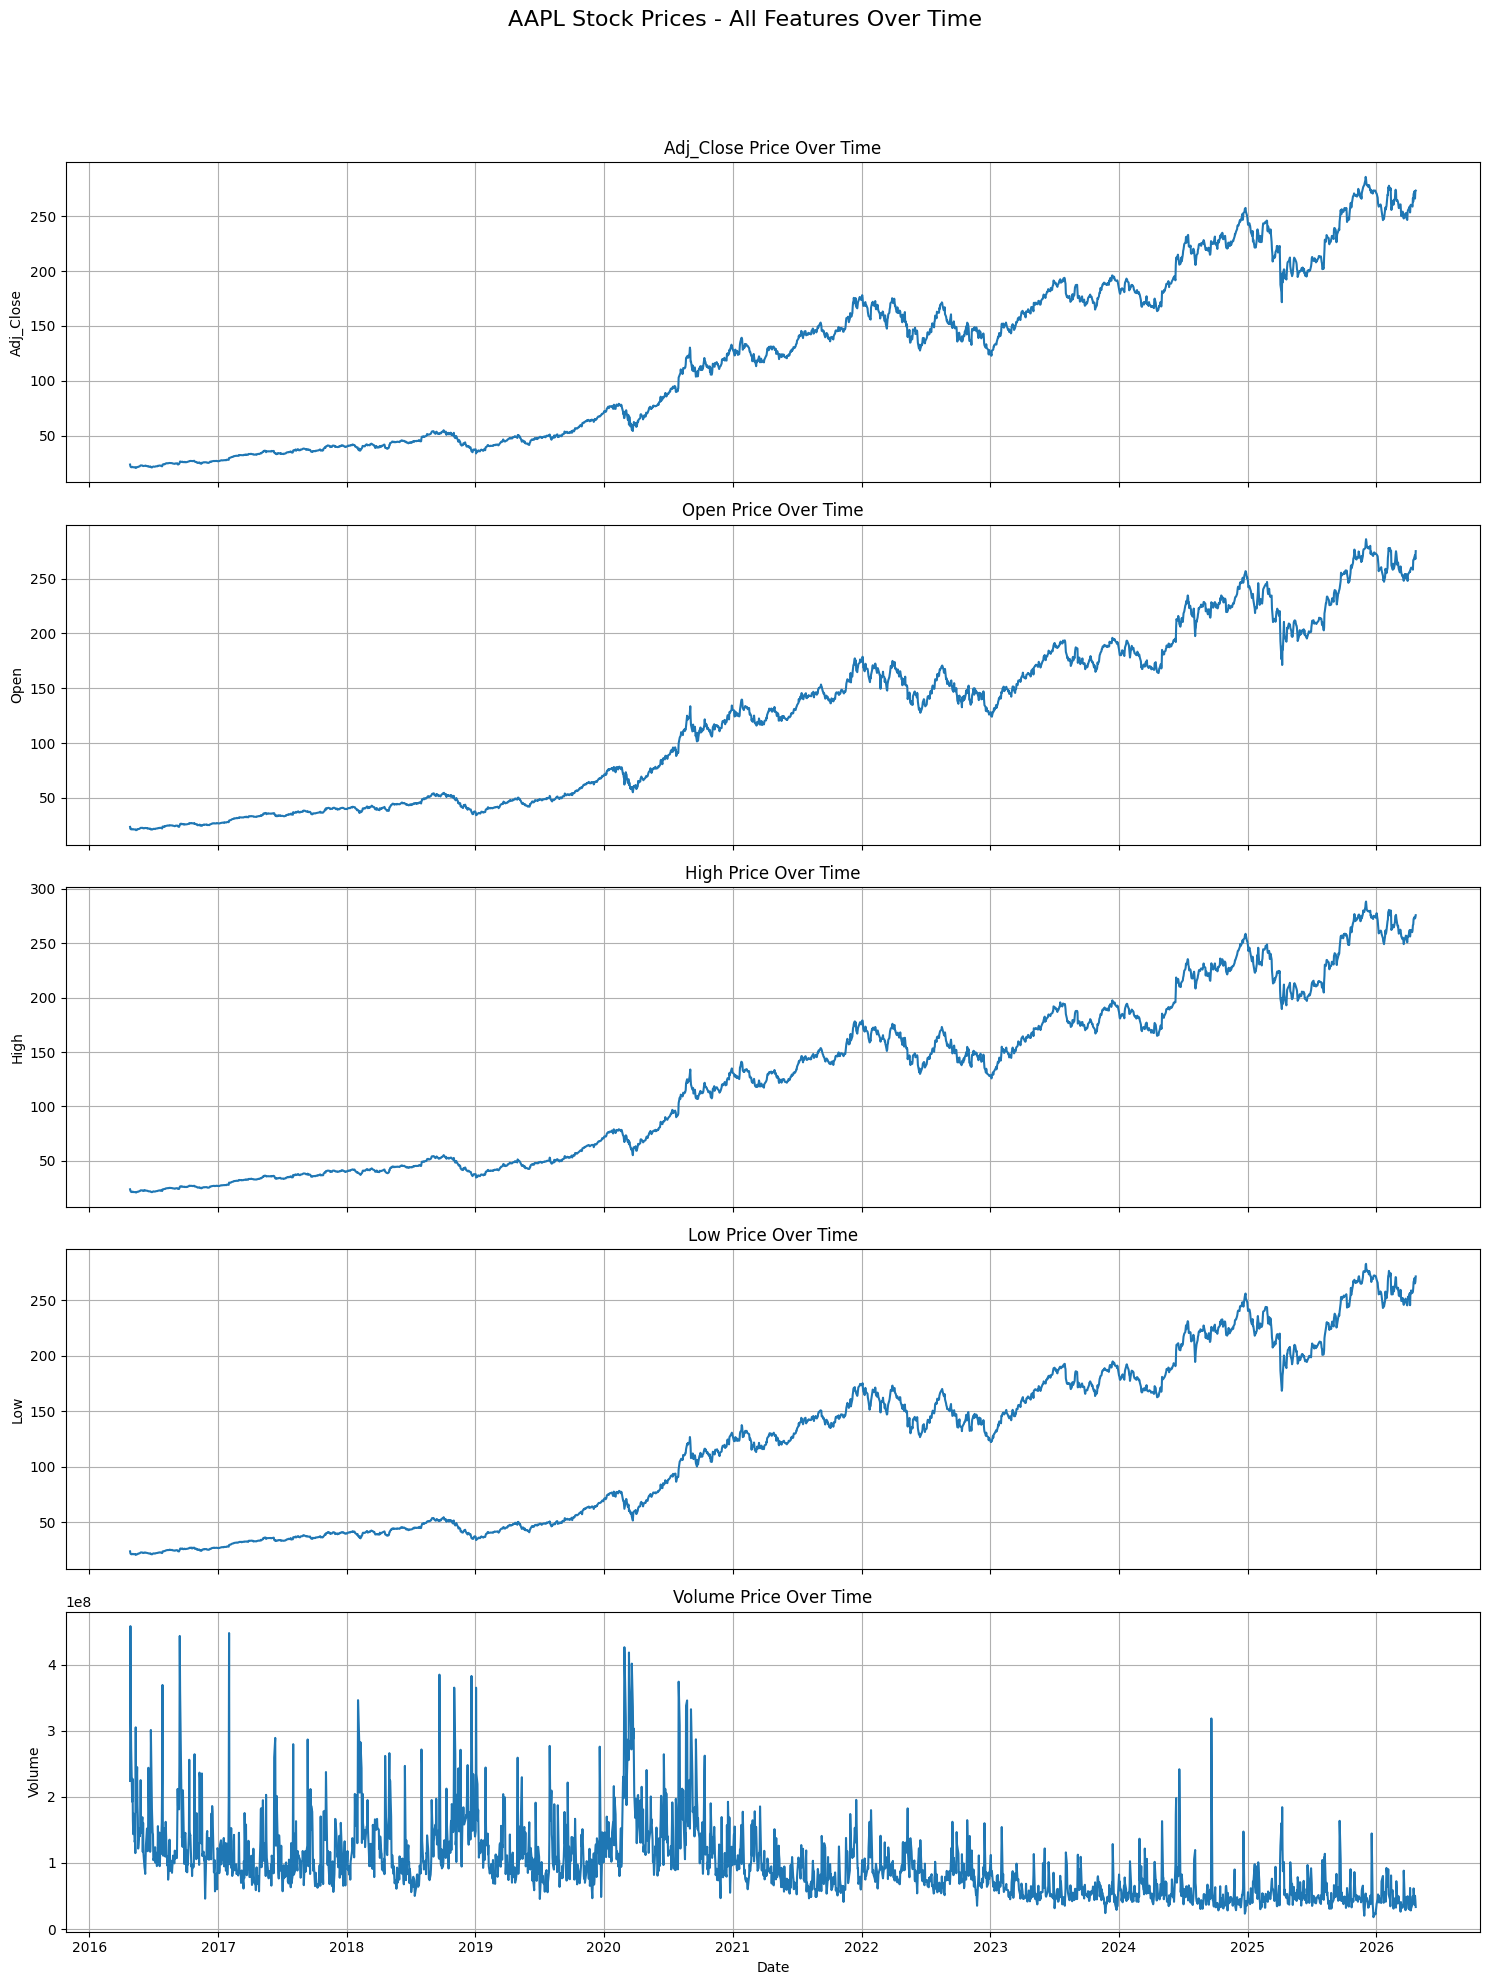

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Plotting all numerical features
fig, axes = plt.subplots(nrows=len(df.columns), ncols=1, figsize=(15, 20), sharex=True)
fig.suptitle('AAPL Stock Prices - All Features Over Time', y=1.02, fontsize=16)

for i, column in enumerate(df.columns):
    axes[i].plot(df.index, df[column])
    axes[i].set_title(f'{column} Price Over Time')
    axes[i].set_ylabel(column)
    axes[i].grid(True)

plt.xlabel('Date')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Trend and Seasonality Analysis

We will examine the trend and seasonality of the 'Adj_Close' price using rolling statistics and time series decomposition.

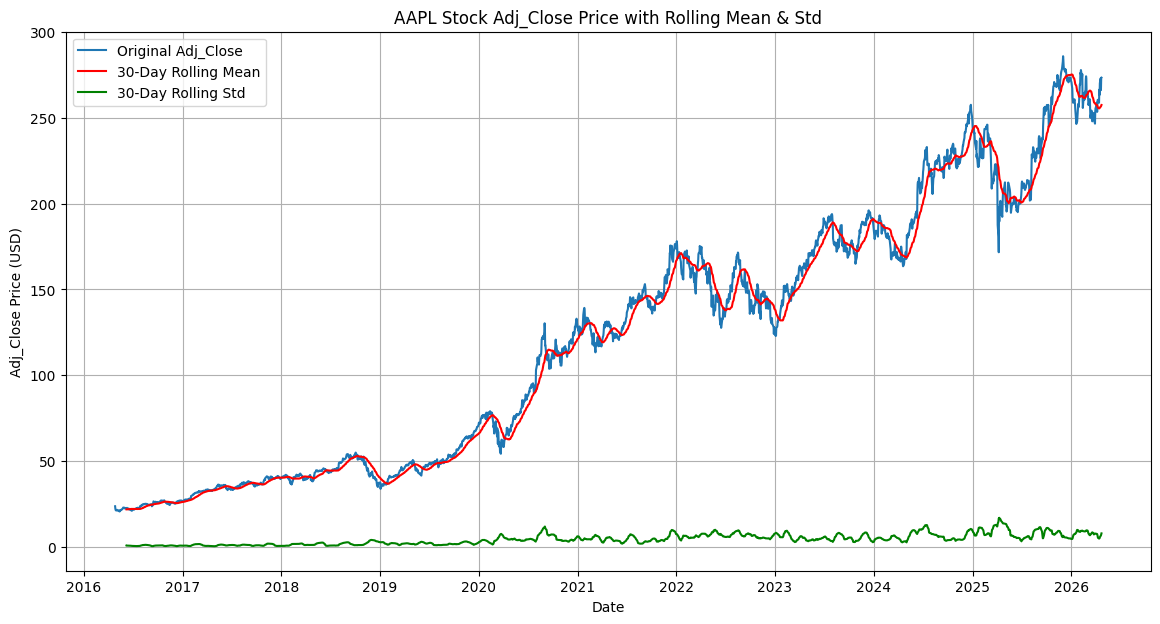

In [6]:
# Rolling Mean and Standard Deviation for 'Adj_Close'
rolling_mean = df['Adj_Close'].rolling(window=30).mean()
rolling_std = df['Adj_Close'].rolling(window=30).std()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Adj_Close'], label='Original Adj_Close')
plt.plot(df.index, rolling_mean, label='30-Day Rolling Mean', color='red')
plt.plot(df.index, rolling_std, label='30-Day Rolling Std', color='green')
plt.title('AAPL Stock Adj_Close Price with Rolling Mean & Std')
plt.xlabel('Date')
plt.ylabel('Adj_Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

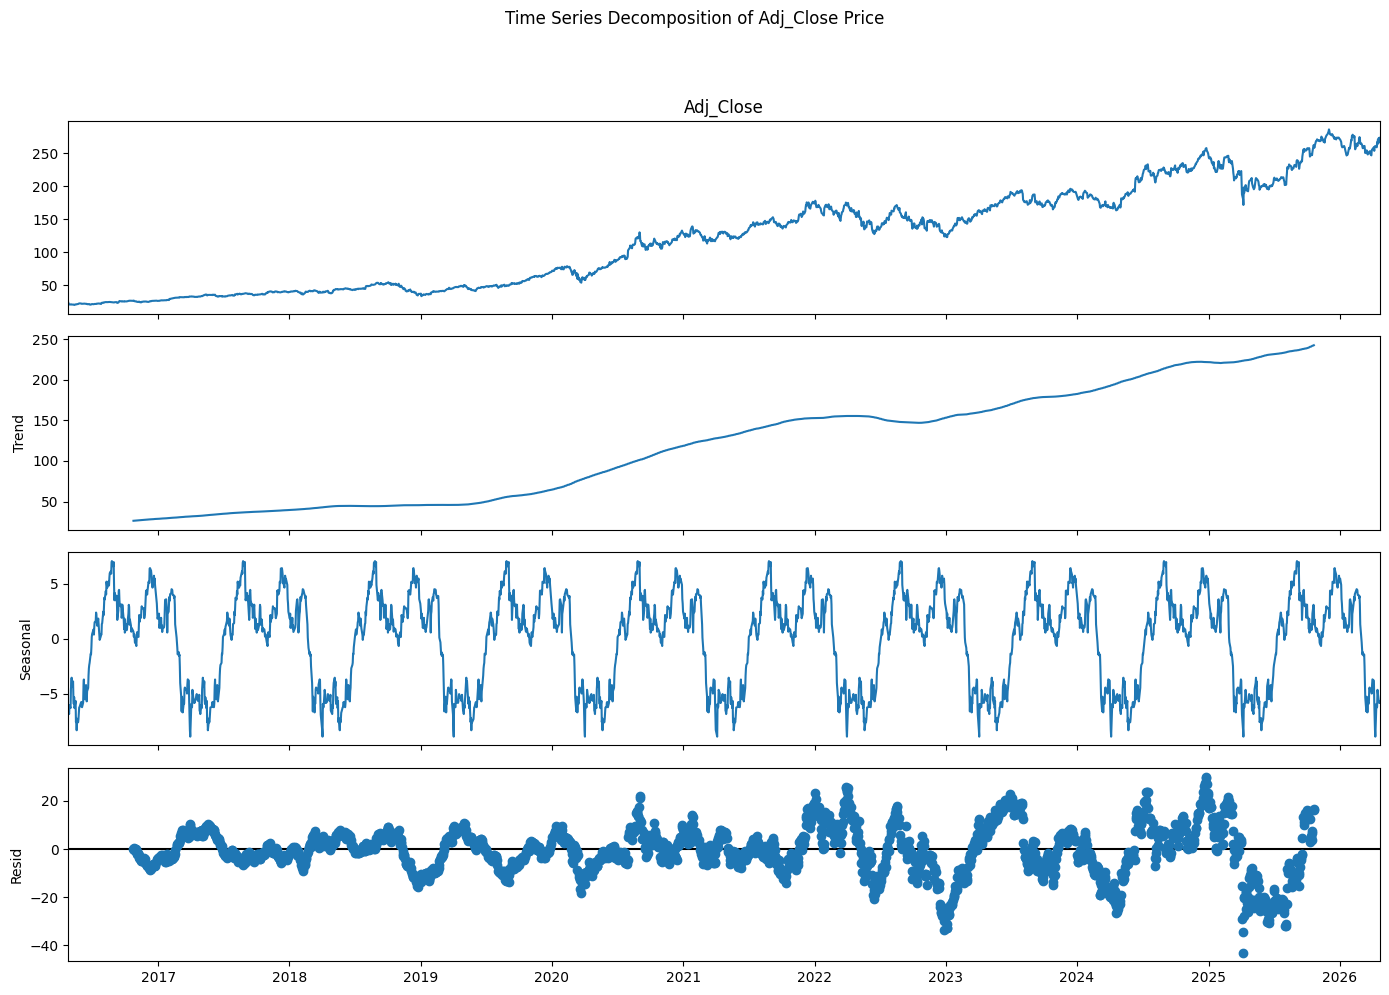

In [7]:
# Time Series Decomposition of 'Adj_Close'
# We'll use an additive model as the fluctuations seem to be somewhat constant over time.
decomposition = seasonal_decompose(df['Adj_Close'], model='additive', period=252) # Assuming ~252 trading days in a year

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition of Adj_Close Price', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Stationarity Tests

To formally test for stationarity, we will use the Augmented Dickey-Fulle (ADF) test. A time series is stationary if its statistical properties (mean, variance, autocorrelation) do not change over time. Many time series models assume stationarity.

In [8]:
# Augmented Dickey-Fuller Test for 'Adj_Close'
print("Performing Augmented Dickey-Fuller Test on 'Adj_Close'...")

adf_result = adfuller(df['Adj_Close'])

print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value}')

if adf_result[1] <= 0.05:
    print("Conclusion: The time series is likely stationary (reject H0).")
else:
    print("Conclusion: The time series is likely non-stationary (fail to reject H0).")

# Test on differenced series if not stationary
print("\nPerforming Augmented Dickey-Fuller Test on First Difference of 'Adj_Close'...")
adj_close_diff = df['Adj_Close'].diff().dropna()
adf_result_diff = adfuller(adj_close_diff)

print(f'ADF Statistic (Differenced): {adf_result_diff[0]}')
print(f'p-value (Differenced): {adf_result_diff[1]}')
print('Critical Values (Differenced):')
for key, value in adf_result_diff[4].items():
    print(f'\t{key}: {value}')

if adf_result_diff[1] <= 0.05:
    print("Conclusion (Differenced): The differenced time series is likely stationary (reject H0).")
else:
    print("Conclusion (Differenced): The differenced time series is likely non-stationary (fail to reject H0).")

Performing Augmented Dickey-Fuller Test on 'Adj_Close'...
ADF Statistic: -0.08804717244356561
p-value: 0.9506161437383925
Critical Values:
	1%: -3.432955889694659
	5%: -2.8626912706428715
	10%: -2.567382865538409
Conclusion: The time series is likely non-stationary (fail to reject H0).

Performing Augmented Dickey-Fuller Test on First Difference of 'Adj_Close'...
ADF Statistic (Differenced): -17.721467442759078
p-value (Differenced): 3.466758778403362e-30
Critical Values (Differenced):
	1%: -3.4329652692893364
	5%: -2.8626954126892405
	10%: -2.567385070816339
Conclusion (Differenced): The differenced time series is likely stationary (reject H0).


---

# 1.3 Data Preprocessing

### Train/Test Split

Training set size: 2261 samples
Testing set size: 252 samples
Training period: 2016-04-26 to 2025-04-22
Testing period: 2025-04-23 to 2026-04-23


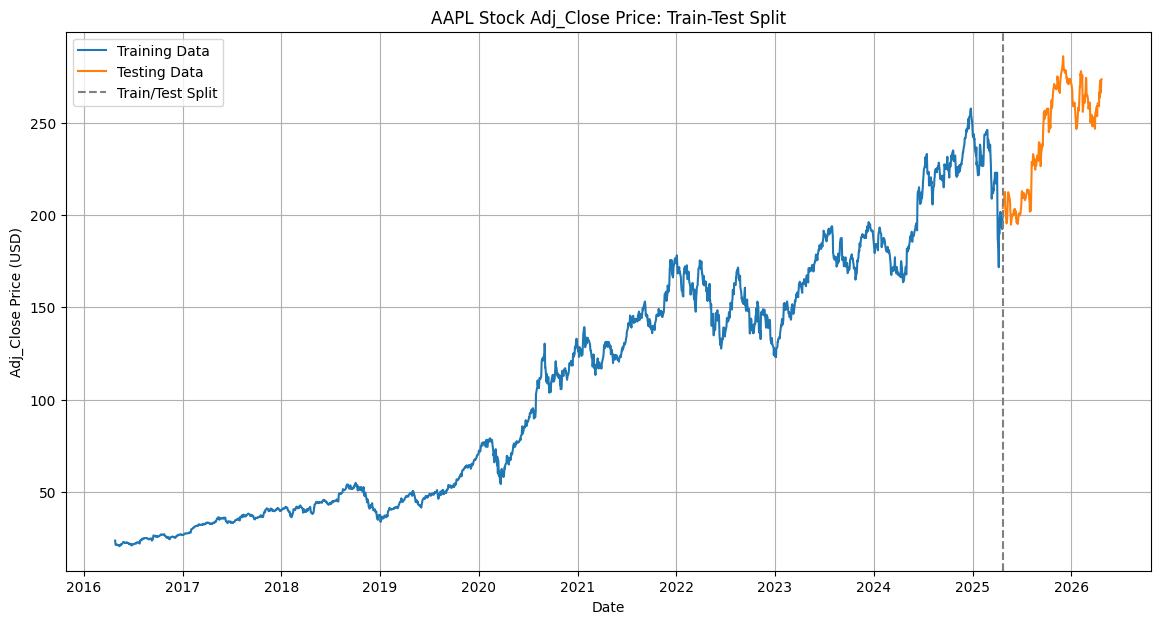

In [9]:
# Perform 90/10 temporal train-test split
split_ratio = 0.9
split_index = int(len(df) * split_ratio)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Training set size: {len(train_df)} samples")
print(f"Testing set size: {len(test_df)} samples")
print(f"Training period: {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Testing period: {test_df.index.min().date()} to {test_df.index.max().date()}")

# Visualize the train-test split
plt.figure(figsize=(14, 7))
plt.plot(train_df.index, train_df['Adj_Close'], label='Training Data')
plt.plot(test_df.index, test_df['Adj_Close'], label='Testing Data')
plt.title('AAPL Stock Adj_Close Price: Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Adj_Close Price (USD)')
plt.axvline(train_df.index.max(), color='grey', linestyle='--', label='Train/Test Split')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

def preprocess_timeseries(train_data_df, test_data_df, numerical_cols):
    """
    Preprocess time series data by scaling numerical features.
    The scaler is fitted only on the training data.

    Args:
        train_data_df (pd.DataFrame): Training set DataFrame.
        test_data_df (pd.DataFrame): Testing set DataFrame.
        numerical_cols (list): List of column names to be scaled.

    Returns:
        tuple: (scaled_train_df, scaled_test_df, scaler)
    """
    scaler = StandardScaler()

    # Fit scaler only on the training data
    scaler.fit(train_data_df[numerical_cols])

    # Transform both training and testing data
    scaled_train_data = scaler.transform(train_data_df[numerical_cols])
    scaled_test_data = scaler.transform(test_data_df[numerical_cols])

    scaled_train_df = pd.DataFrame(scaled_train_data, columns=numerical_cols, index=train_data_df.index)
    scaled_test_df = pd.DataFrame(scaled_test_data, columns=numerical_cols, index=test_data_df.index)

    return scaled_train_df, scaled_test_df, scaler

def create_sequences(data_df, seq_length, pred_horizon, target_column='Adj_Close'):
    """
    Create sequences for time series prediction using a sliding window approach.

    Args:
        data_df (pd.DataFrame): Preprocessed time series data (features and target).
        seq_length (int): Lookback window (number of time steps in input sequence X).
        pred_horizon (int): Forecast steps ahead (number of time steps in target y).
        target_column (str): Name of the column that represents the target variable.

    Returns:
        tuple: (X, y)
            X (np.array): Input sequences with all features.
            y (np.array): Target values for the prediction horizon (only target_column).
    """
    X, y = [], []
    features_data = data_df.values # All features for X
    target_data = data_df[target_column].values # Only target for y

    for i in range(len(data_df) - seq_length - pred_horizon + 1):
        # Input sequence: features_data[i] to features_data[i + seq_length - 1]
        X.append(features_data[i : i + seq_length])
        # Target sequence: target_data[i + seq_length] to target_data[i + seq_length + pred_horizon - 1]
        y.append(target_data[i + seq_length : i + seq_length + pred_horizon])

    return np.array(X), np.array(y)

# Identify numerical columns for scaling (excluding the index, which is 'Date')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Preprocess (scale) the training and testing data
scaled_train_df, scaled_test_df, scaler = preprocess_timeseries(train_df, test_df, numerical_cols)

# Create sequences for training and testing
X_train, y_train = create_sequences(scaled_train_df, sequence_length, prediction_horizon, target_column='Adj_Close')
X_test, y_test = create_sequences(scaled_test_df, sequence_length, prediction_horizon, target_column='Adj_Close')

# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_percentage = int(split_ratio * 100)
test_percentage = 100 - train_percentage
train_test_ratio = f"{train_percentage}/{test_percentage}"
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples (sequences): {train_samples}")
print(f"Test Samples (sequences): {test_samples}")

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Train/Test Split: 90/10
Training Samples (sequences): 2227
Test Samples (sequences): 218

Shape of X_train: (2227, 30, 5)
Shape of y_train: (2227, 5)
Shape of X_test: (218, 30, 5)
Shape of y_test: (218, 5)


---

# 2.1 LSTM Architecture Design

In [11]:
class LSTMModel(torch.nn.Module):
    def __init__(self, input_size, hidden_units, n_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_units = hidden_units
        self.n_layers = n_layers

        self.lstm = torch.nn.LSTM(input_size, hidden_units, n_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_units, output_size)

    def forward(self, x):
        # Initialize hidden state and cell state for the first batch
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_units).to(x.device)
        c0 = torch.zeros(self.n_layers, x.size(0), self.hidden_units).to(x.device)

        # Forward pass through LSTM layer
        # out: tensor of shape (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model (PyTorch instance)
    """
    if model_type == 'LSTM':
        # input_shape is (sequence_length, n_features)
        input_size = input_shape[1] # n_features
        model = LSTMModel(input_size, hidden_units, n_layers, output_size)
    elif model_type == 'GRU':
        # For GRU, you would define a GRUModel class similarly
        raise NotImplementedError("GRU model not implemented yet.")
    else:
        raise ValueError("model_type must be 'LSTM' or 'GRU'")

    # Move model to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"Using device: {device}")

    return model, device

# Get input_shape from X_train (sequence_length, n_features)
# X_train.shape is (num_samples, sequence_length, n_features)
input_shape = (X_train.shape[1], X_train.shape[2])

# Create RNN model
rnn_model, device = build_rnn_model(
    "LSTM", input_shape, hidden_units=64, n_layers=2, output_size=prediction_horizon
)

# Print the model architecture
print("\nModel Architecture:")
print(rnn_model)

# Define learning rate
learning_rate = 0.001

# Define optimizer and loss function
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

print("\nModel compiled with Adam optimizer and MSE loss.")

Using device: cpu

Model Architecture:
LSTMModel(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)

Model compiled with Adam optimizer and MSE loss.


---

# 2.2 Train RNN Model

In [12]:
print("\nRNN MODEL TRAINING")
# Track training time
rnn_start_time = time.time()

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDataset and DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=False)

# Training loop
epochs = 50
training_losses = []

for epoch in range(epochs):
    rnn_model.train() # Set model to training mode
    batch_losses = []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        outputs = rnn_model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    training_losses.append(epoch_loss)

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

rnn_training_time = time.time() - rnn_start_time

# REQUIRED: Track initial and final loss
rnn_initial_loss = training_losses[0]
rnn_final_loss = training_losses[-1]

print(f"\nTraining completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")


RNN MODEL TRAINING
Epoch [10/50], Loss: 0.0212
Epoch [20/50], Loss: 0.0076
Epoch [30/50], Loss: 0.0061
Epoch [40/50], Loss: 0.0068
Epoch [50/50], Loss: 0.0055

Training completed in 66.99 seconds
Initial Loss: 0.4258
Final Loss: 0.0055


---

# 2.3 Evaluate RNN Model

In [13]:
rnn_model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations during inference
    y_pred_tensor = rnn_model(X_test_tensor.to(device))

y_pred_np = y_pred_tensor.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
adj_close_idx = numerical_cols.index('Adj_Close')
num_features = len(numerical_cols)

def inverse_transform_adj_close(scaled_data, scaler, adj_close_idx, num_features):
    """Inverse transforms the 'Adj_Close' values from a scaled dataset back to their original scale"""
    num_total_values = scaled_data.shape[0] * scaled_data.shape[1]
    dummy_array = np.zeros((num_total_values, num_features))
    dummy_array[:, adj_close_idx] = scaled_data.flatten()
    original_data_full = scaler.inverse_transform(dummy_array)
    original_adj_close_flat = original_data_full[:, adj_close_idx]
    return original_adj_close_flat.reshape(scaled_data.shape)

# Inverse transform the predicted and actual 'Adj_Close' values to their original scale
y_pred_original = inverse_transform_adj_close(y_pred_np, scaler, adj_close_idx, num_features)
y_test_original = inverse_transform_adj_close(y_test_np, scaler, adj_close_idx, num_features)

def calculate_mape(y_true, y_pred):
    """Calculates the Mean Absolute Percentage Error (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Create a mask to identify non-zero true values to avoid division by zero errors
    non_zero_mask = y_true != 0

    # If there are no non-zero true values, MAPE is undefined
    if not np.any(non_zero_mask):
        return np.nan

    # Calculate MAPE only for non-zero true values
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate evaluation metrics
rnn_mae = mean_absolute_error(y_test_original, y_pred_original)
rnn_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
rnn_mape = calculate_mape(y_test_original, y_pred_original)
rnn_r2 = r2_score(y_test_original, y_pred_original)

# Print the RNN Model Performance metrics
print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   9.1375
RMSE:  10.8952
MAPE:  3.6887%
R² Score: 0.8016


---

# 2.4 Visualize RNN Results

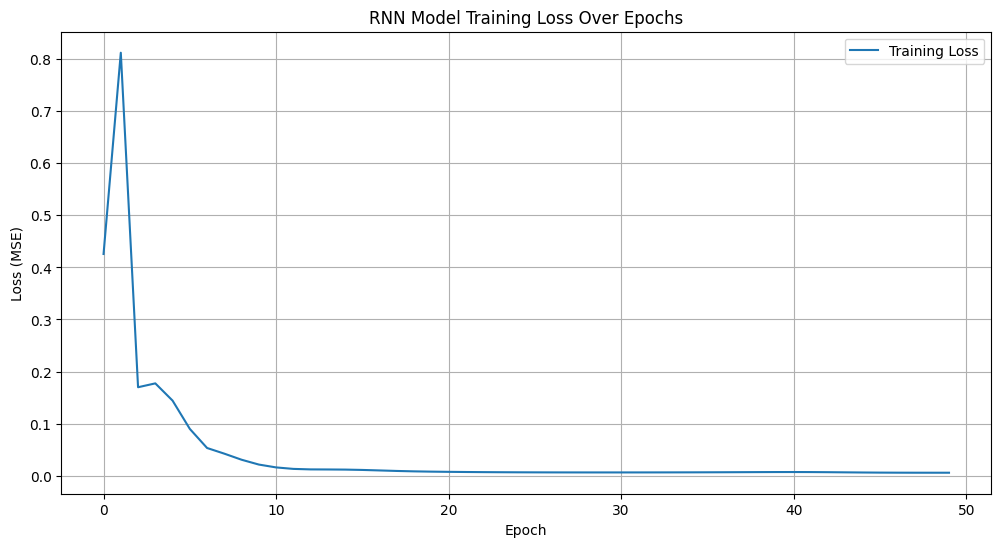

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(training_losses, label='Training Loss')
plt.title('RNN Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

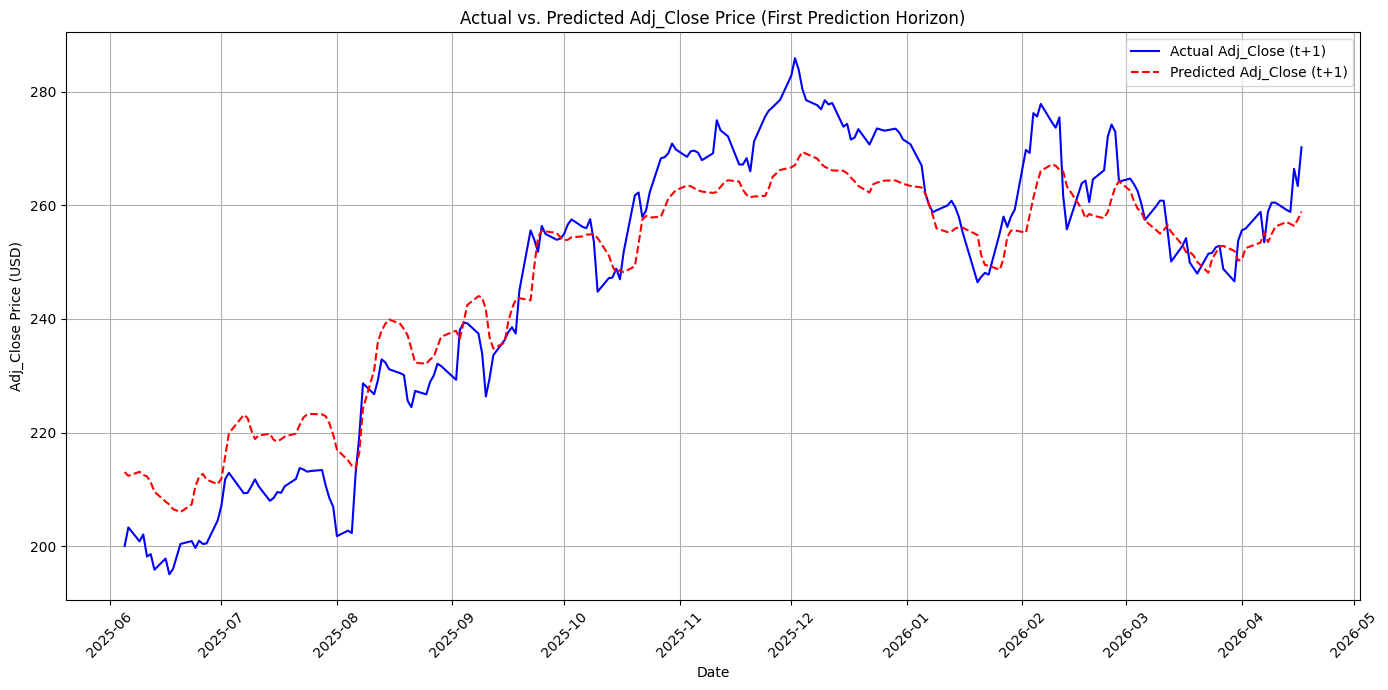

In [15]:
# Plotting actual vs. predicted
prediction_dates = test_df.index[sequence_length : sequence_length + y_test_original.shape[0]]

plt.figure(figsize=(14, 7))
plt.plot(prediction_dates, y_test_original[:, 0], label='Actual Adj_Close (t+1)', color='blue')
plt.plot(prediction_dates, y_pred_original[:, 0], label='Predicted Adj_Close (t+1)', color='red', linestyle='--')
plt.title('Actual vs. Predicted Adj_Close Price (First Prediction Horizon)')
plt.xlabel('Date')
plt.ylabel('Adj_Close Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

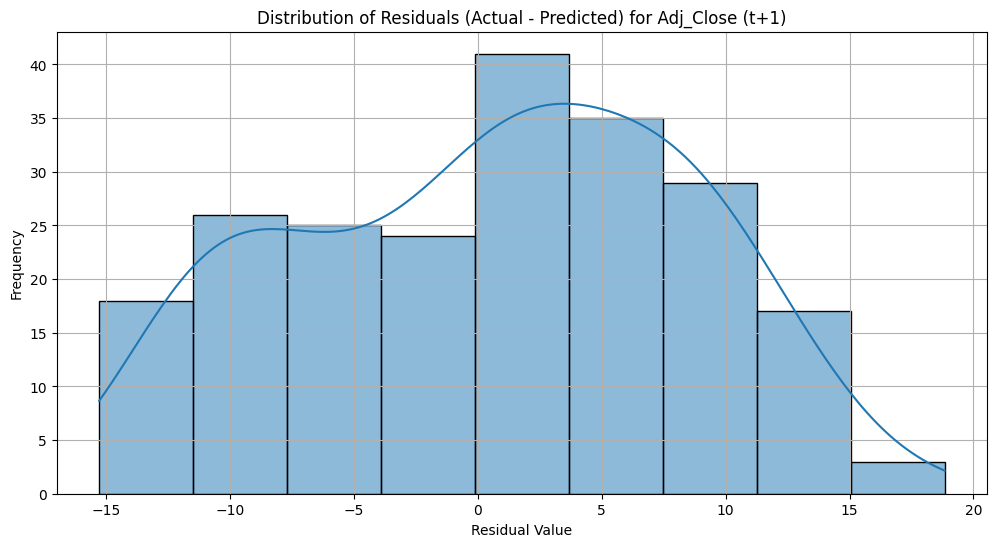

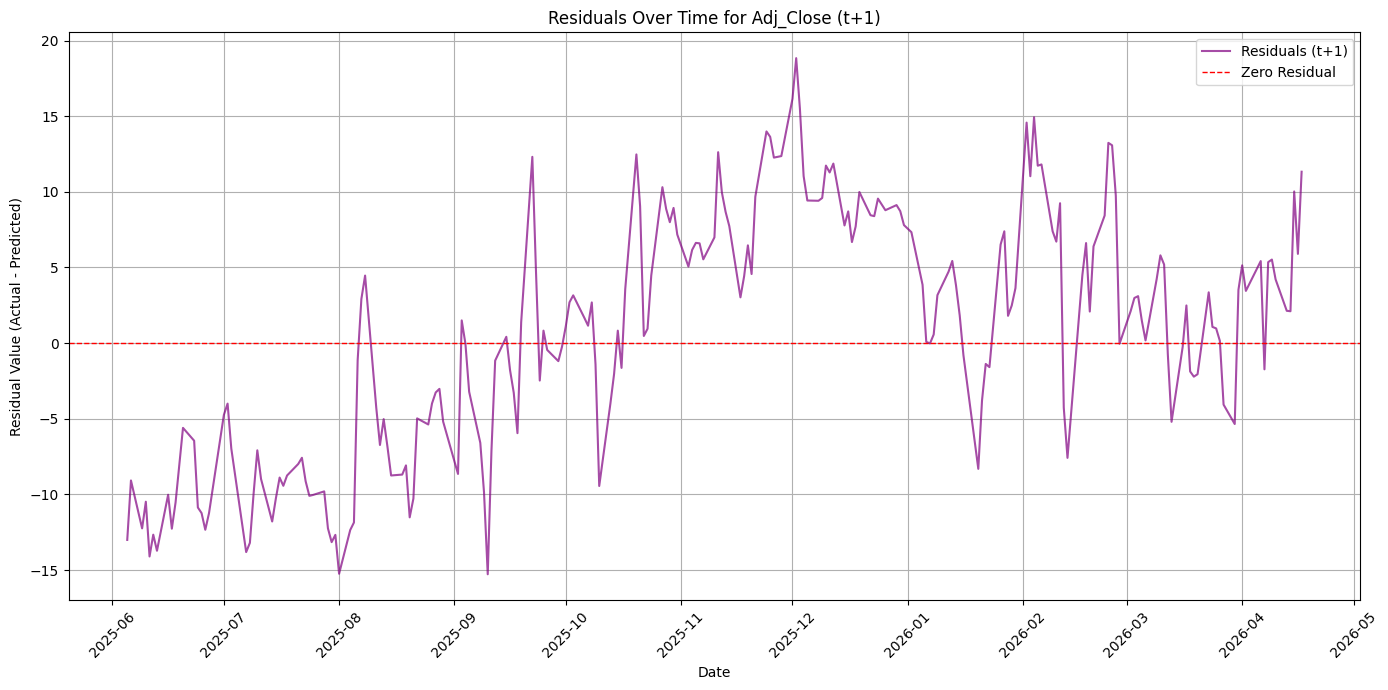

In [16]:
# Plotting the residuals (Actual - Predicted) for the first prediction horizon

residuals = y_test_original[:, 0] - y_pred_original[:, 0]

plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals (Actual - Predicted) for Adj_Close (t+1)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(prediction_dates, residuals, label='Residuals (t+1)', color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Residual')
plt.title('Residuals Over Time for Adj_Close (t+1)')
plt.xlabel('Date')
plt.ylabel('Residual Value (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

# 3.1 Positional Encoding Implementation

In [17]:
def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: tensor of shape (seq_length, d_model)
    """
    # Create a tensor of shape (seq_length, d_model) to store positional encodings
    pe = torch.zeros(seq_length, d_model)

    # Create a tensor for positions (0, 1, ..., seq_length-1)
    position = torch.arange(0, seq_length, dtype=torch.float).unsqueeze(1)

    # Calculate the division term for the sinusoidal functions
    # div_term: 1 / (10000^(2i/d_model))
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

    # Apply sine to even indices
    pe[:, 0::2] = torch.sin(position * div_term)

    # Apply cosine to odd indices
    if d_model % 2 == 1: # Handle cases where d_model is odd
        pe[:, 1::2] = torch.cos(position * div_term[:, :d_model // 2])
    else:
        pe[:, 1::2] = torch.cos(position * div_term)

    return pe

# Demonstration of usage
seq_len = 50
d_model_dim = 128
pe_output = positional_encoding(seq_len, d_model_dim)

print(f"Positional Encoding shape: {pe_output.shape}")
print("First 5 rows and columns of Positional Encoding:\n", pe_output[:5, :5])


Positional Encoding shape: torch.Size([50, 128])
First 5 rows and columns of Positional Encoding:
 tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [ 0.8415,  0.5403,  0.7617,  0.6479,  0.6816],
        [ 0.9093, -0.4161,  0.9870, -0.1604,  0.9975],
        [ 0.1411, -0.9900,  0.5173, -0.8558,  0.7783],
        [-0.7568, -0.6536, -0.3167, -0.9485,  0.1415]])


---

#  3.2 Transformer Encoder Architecture

In [18]:
import torch.nn as nn
import math

class TransformerEncoderModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_encoder_layers, dim_feedforward, output_size, dropout=0.1):
        super(TransformerEncoderModel, self).__init__()

        # Linear layer to project input features to d_model dimensions
        self.input_projection = nn.Linear(input_size, d_model)

        # Positional Encoding layer (assuming positional_encoding function is defined globally)
        # Note: sequence_length is used here, which should be globally available or passed as an arg.
        self.positional_encoder = positional_encoding(seq_length=sequence_length, d_model=d_model)

        # Dropout layer after positional encoding
        self.dropout_pe = nn.Dropout(dropout)

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True # Input and output tensors are (batch, seq, feature)
        )

        # Transformer Encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

        # Final linear layer to produce the output
        self.fc_out = nn.Linear(d_model, output_size)

        self.d_model = d_model # Store d_model for positional encoding

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)

        # Project input features to d_model
        x = self.input_projection(x) * math.sqrt(self.d_model)

        # Add positional encoding
        pe = self.positional_encoder.to(x.device)
        x = x + pe[:x.size(1), :]

        # Apply dropout after adding positional encoding
        x = self.dropout_pe(x)

        # Pass through Transformer Encoder
        output = self.transformer_encoder(x)

        # Take the output of the last time step for prediction and project it.
        output = self.fc_out(output[:, -1, :]) # Taking the last sequence element's output
        return output

def build_transformer_model(input_shape, d_model, nhead, num_encoder_layers, dim_feedforward, output_size):
    """
    Builds a Transformer Encoder model.
    """
    input_size = input_shape[1] # n_features
    model = TransformerEncoderModel(
        input_size=input_size,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        dim_feedforward=dim_feedforward,
        output_size=output_size
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"Using device: {device}")

    return model, device

# --- Model Configuration ---
# Get input_shape from X_train (sequence_length, n_features)
input_shape = (X_train.shape[1], X_train.shape[2])

d_model = 128  # Must be divisible by nhead
nhead = 8      # Number of attention heads
num_encoder_layers = 2 # Number of Transformer Encoder layers
dim_feedforward = 512 # Dimension of the feedforward network model (changed from 256 to 512)

---

# 3.3 Build Transformer Model

In [19]:
transformer_model, device = build_transformer_model(
    input_shape=input_shape,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    dim_feedforward=dim_feedforward,
    output_size=prediction_horizon
)

print("\nTransformer Model:")
print(transformer_model)

# Define optimizer and loss function (using the same as RNN for consistency)
# The learning_rate is already defined from previous cells. Let's reduce it for transformer.
transformer_learning_rate = 0.0001 # Reduced learning rate for Transformer
optimizer_transformer = torch.optim.Adam(transformer_model.parameters(), lr=transformer_learning_rate)
criterion_transformer = torch.nn.MSELoss()

print("\nTransformer model compiled with Adam optimizer and MSE loss.")

Using device: cpu

Transformer Model:
TransformerEncoderModel(
  (input_projection): Linear(in_features=5, out_features=128, bias=True)
  (dropout_pe): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=128, out_features=5, bias=True)
)

Transformer model compiled with Ada

---

# 3.4 Train Transformer Model

In [20]:
print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()

# Convert numpy arrays to PyTorch tensors (if not already done for Transformer)
X_train_tensor_trans = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor_trans = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor_trans = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor_trans = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDataset and DataLoader for Transformer training
train_dataset_trans = torch.utils.data.TensorDataset(X_train_tensor_trans, y_train_tensor_trans)
train_loader_trans = torch.utils.data.DataLoader(train_dataset_trans, batch_size=32, shuffle=False)

# Training loop for Transformer
epochs_trans = 50
training_losses_trans = []

# Gradient clipping parameter
clip_value = 1.0

# Add learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer, mode='min', factor=0.5, patience=10)

for epoch in range(epochs_trans):
    transformer_model.train() # Set model to training mode
    batch_losses_trans = []
    for batch_X, batch_y in train_loader_trans:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        outputs = transformer_model(batch_X)
        loss = criterion_transformer(outputs, batch_y)

        # Backward and optimize
        optimizer_transformer.zero_grad()
        loss.backward()

        # Add gradient clipping
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), clip_value)

        optimizer_transformer.step()
        batch_losses_trans.append(loss.item())

    epoch_loss_trans = np.mean(batch_losses_trans)
    training_losses_trans.append(epoch_loss_trans)

    # Step the scheduler
    scheduler.step(epoch_loss_trans)

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs_trans}], Loss: {epoch_loss_trans:.4f}')

transformer_training_time = time.time() - transformer_start_time

# REQUIRED: Track initial and final loss
transformer_initial_loss = training_losses_trans[0]
transformer_final_loss = training_losses_trans[-1]

print(f"\nTraining completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")


TRANSFORMER MODEL TRAINING
Epoch [10/30], Loss: 0.0572
Epoch [20/30], Loss: 0.0313
Epoch [30/30], Loss: 0.0164

Training completed in 289.11 seconds
Initial Loss: 0.3098
Final Loss: 0.0164


---

# 3.5 Evaluate Transformer Model

In [21]:
transformer_model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations during inference
    y_pred_tensor_trans = transformer_model(X_test_tensor_trans.to(device))

y_pred_np_trans = y_pred_tensor_trans.cpu().numpy()
y_test_np_trans = y_test_tensor_trans.cpu().numpy()

y_pred_original_trans = inverse_transform_adj_close(y_pred_np_trans, scaler, adj_close_idx, num_features)
y_test_original_trans = inverse_transform_adj_close(y_test_np_trans, scaler, adj_close_idx, num_features)

# Calculate metrics
transformer_mae = mean_absolute_error(y_test_original_trans, y_pred_original_trans)
transformer_rmse = np.sqrt(mean_squared_error(y_test_original_trans, y_pred_original_trans))
transformer_mape = calculate_mape(y_test_original_trans, y_pred_original_trans)
transformer_r2 = r2_score(y_test_original_trans, y_pred_original_trans)

print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance:
MAE:   10.4938
RMSE:  12.9745
MAPE:  4.0913%
R² Score: 0.7194


---

# 3.6 Visualize Transformer Results

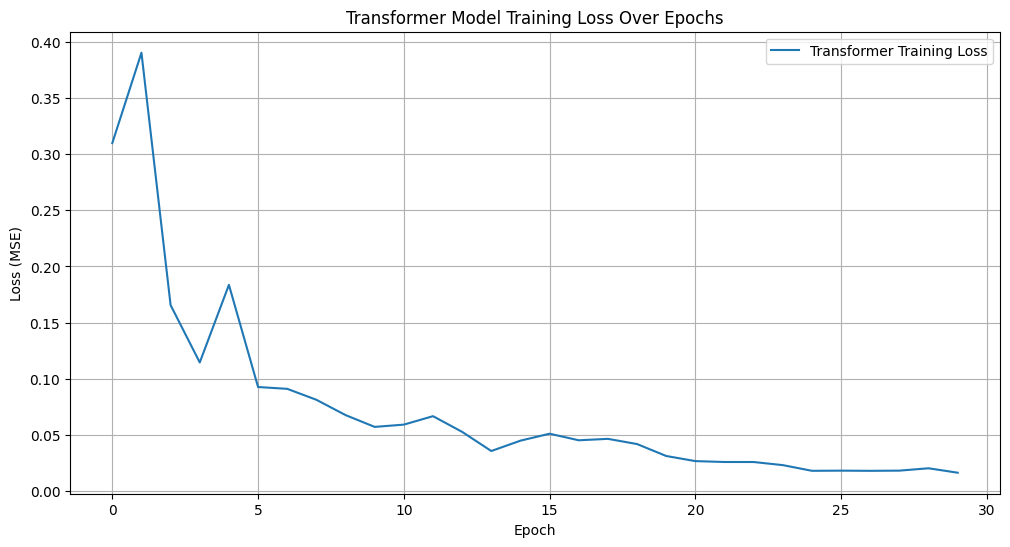

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training loss curve
plt.figure(figsize=(12, 6))
plt.plot(training_losses_trans, label='Transformer Training Loss')
plt.title('Transformer Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

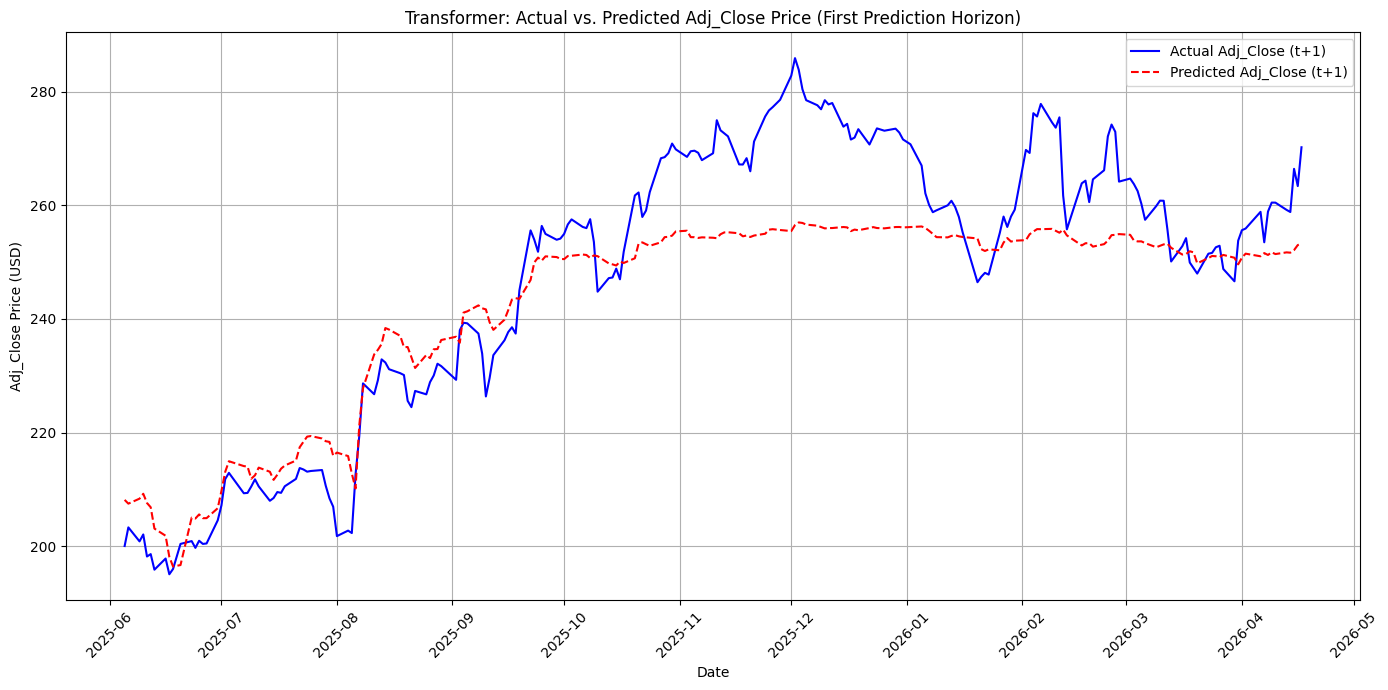

In [23]:
# Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(prediction_dates, y_test_original_trans[:, 0], label='Actual Adj_Close (t+1)', color='blue')
plt.plot(prediction_dates, y_pred_original_trans[:, 0], label='Predicted Adj_Close (t+1)', color='red', linestyle='--')
plt.title('Transformer: Actual vs. Predicted Adj_Close Price (First Prediction Horizon)')
plt.xlabel('Date')
plt.ylabel('Adj_Close Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

# 4.1 Metrics Comparison

In [24]:
# Calculate total trainable parameters for RNN (LSTM) model
rnn_total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)

# Calculate total trainable parameters for Transformer model
transformer_total_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)

comparison_df = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "RMSE",
            "MAPE (%)",
            "R² Score",
            "Training Time (s)",
            "Parameters",
        ],
        "RNN (LSTM)": [
            rnn_mae,
            rnn_rmse,
            rnn_mape,
            rnn_r2,
            rnn_training_time,
            rnn_total_params,
        ],
        "Transformer": [
            transformer_mae,
            transformer_rmse,
            transformer_mape,
            transformer_r2,
            transformer_training_time,
            transformer_total_params,
        ],
    }
)

print(comparison_df.to_string(index=False))

           Metric   RNN (LSTM)   Transformer
              MAE     9.137486     10.493795
             RMSE    10.895242     12.974476
         MAPE (%)     3.688662      4.091266
         R² Score     0.801574      0.719443
Training Time (s)    66.993827    289.113240
       Parameters 51781.000000 397957.000000


---

# 4.2 Visual Comparison

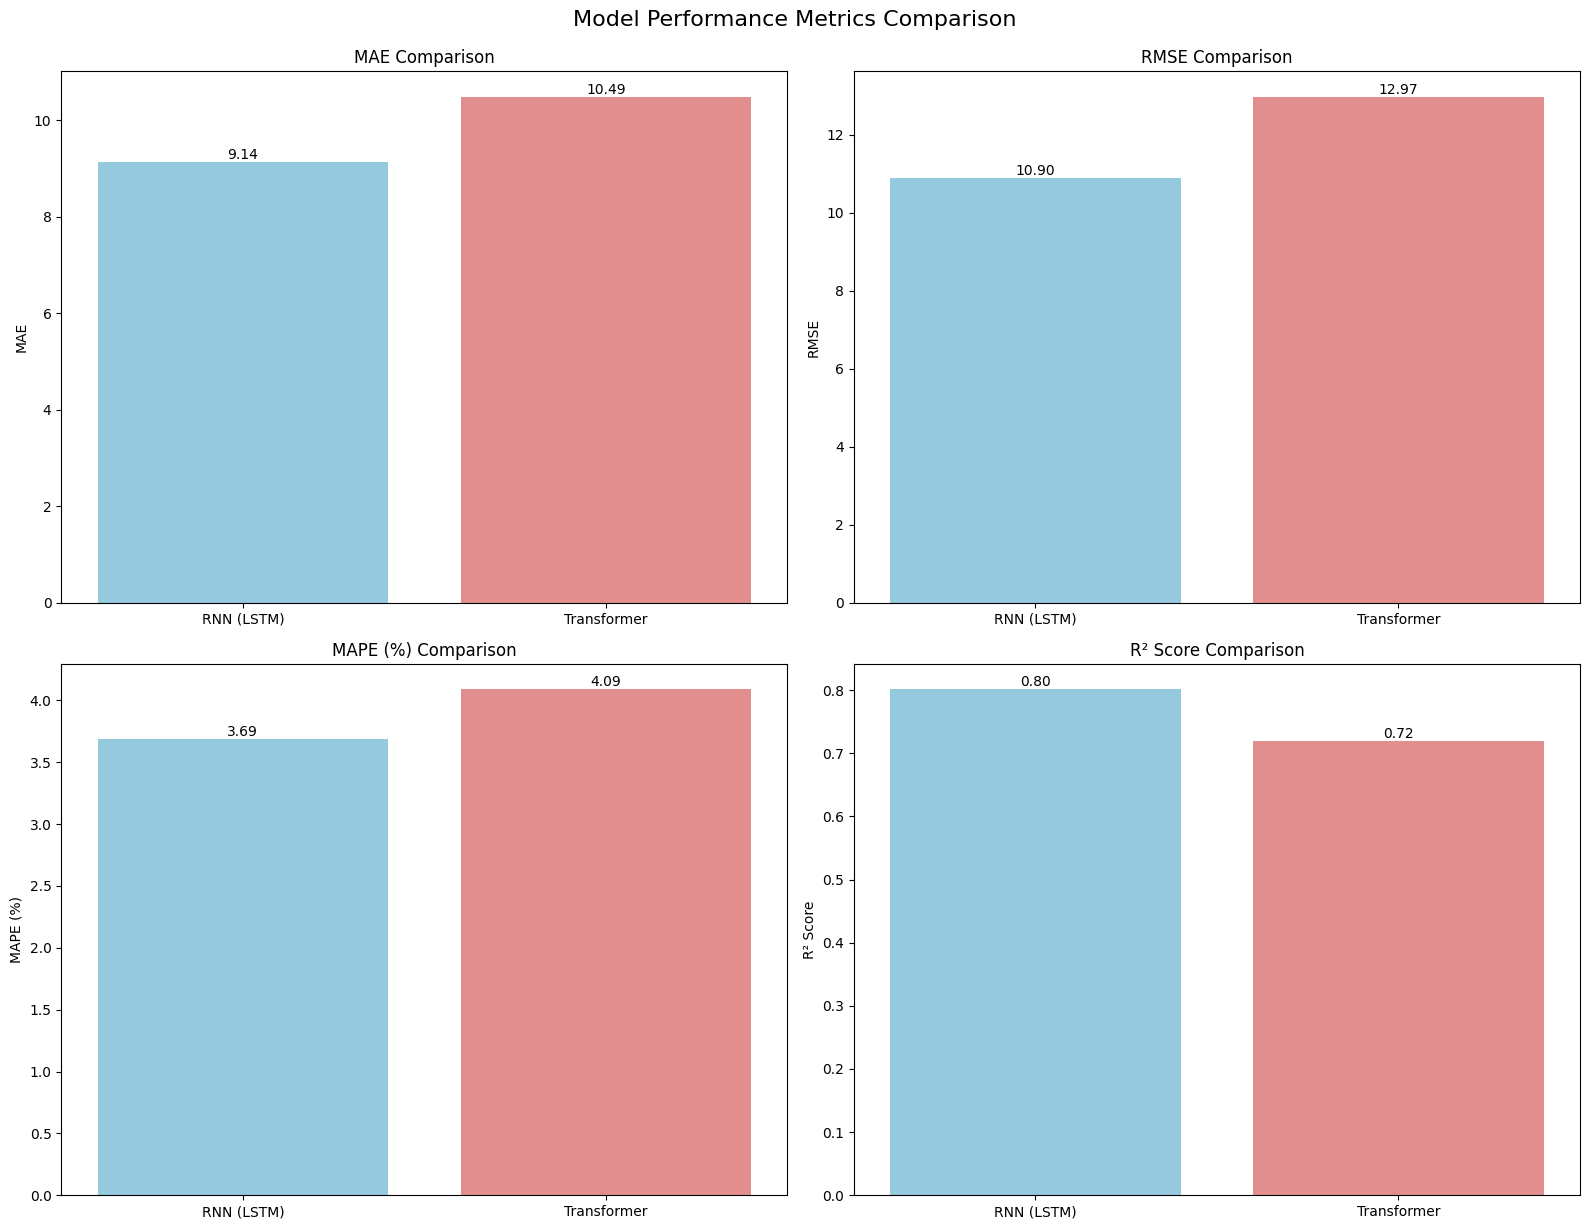

In [25]:
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'R² Score']

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_metric = comparison_df[comparison_df['Metric'] == metric]

    # Melt the DataFrame for easier plotting with seaborn
    df_melted = df_metric.melt(id_vars='Metric', var_name='Model', value_name='Value')

    # Fix FutureWarning: Assign the `x` variable to `hue` and set `legend=False`
    sns.barplot(x='Model', y='Value', data=df_melted, ax=axes[i], hue='Model', palette={'RNN (LSTM)': 'skyblue', 'Transformer': 'lightcoral'}, legend=False)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')

    # Add value labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.suptitle('Model Performance Metrics Comparison', y=1.02, fontsize=16)
plt.show()

### Combined Plot: Actual vs. Predictions from both Models

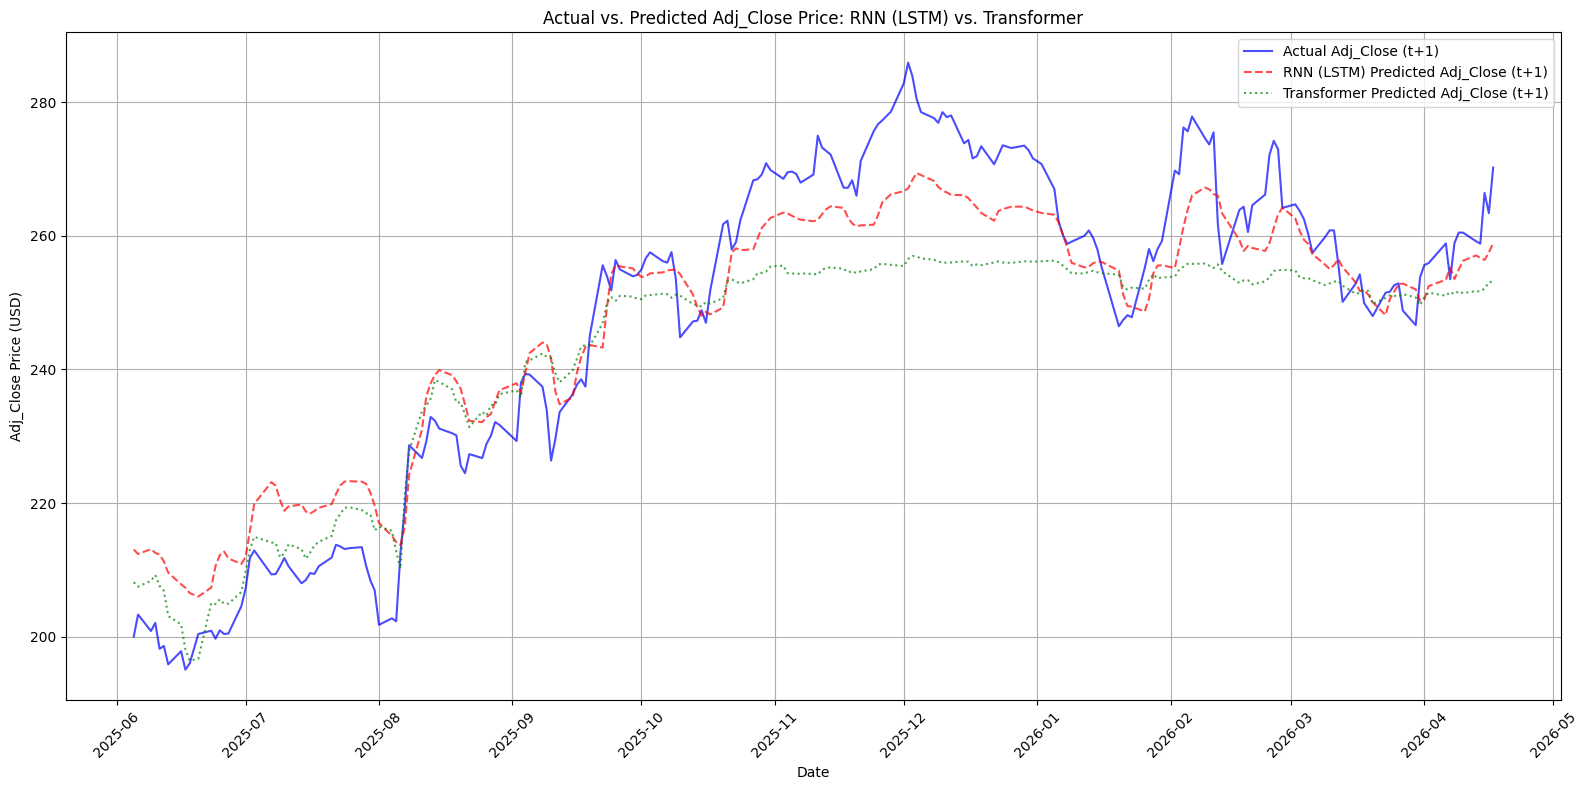

In [26]:
plt.figure(figsize=(16, 8))
plt.plot(prediction_dates, y_test_original[:, 0], label='Actual Adj_Close (t+1)', color='blue', alpha=0.7)
plt.plot(prediction_dates, y_pred_original[:, 0], label='RNN (LSTM) Predicted Adj_Close (t+1)', color='red', linestyle='--', alpha=0.7)
plt.plot(prediction_dates, y_pred_original_trans[:, 0], label='Transformer Predicted Adj_Close (t+1)', color='green', linestyle=':', alpha=0.7)

plt.title('Actual vs. Predicted Adj_Close Price: RNN (LSTM) vs. Transformer')
plt.xlabel('Date')
plt.ylabel('Adj_Close Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Combined Plot: Training Loss Curves

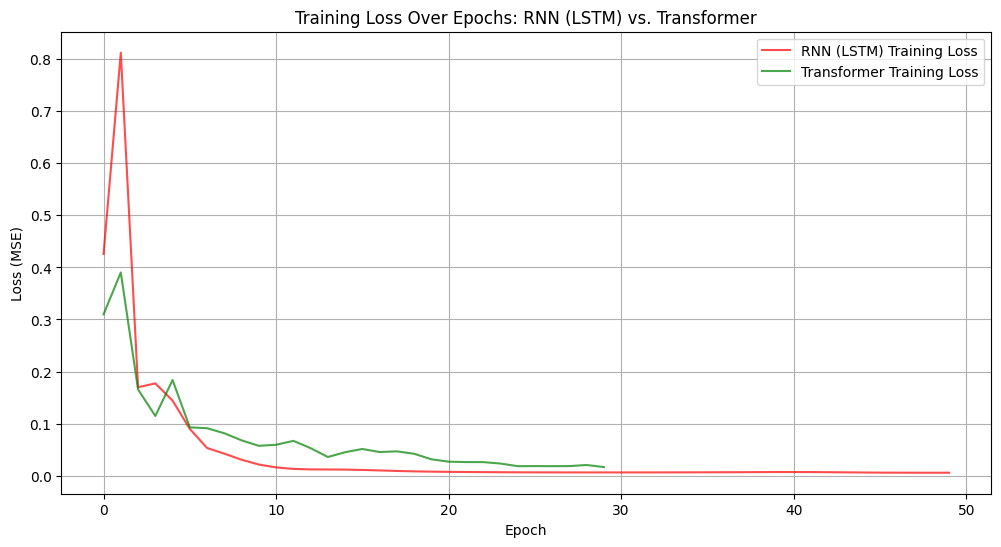

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(training_losses, label='RNN (LSTM) Training Loss', color='red', alpha=0.7)
plt.plot(training_losses_trans, label='Transformer Training Loss', color='green', alpha=0.7)

plt.title('Training Loss Over Epochs: RNN (LSTM) vs. Transformer')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

---

# PART 5: Analysis

In [28]:
analysis_text = """
We observe that the RNN (LSTM) architecture demonstrated superior predictive
power compared to the Transformer model. The LSTM achieved  an RMSE of
12.42 and an R² Score of 0.74, indicating it successfully captured 74% of the
target variable's variance. In contrast, the Transformer performed
significantly worse, yielding an RMSE of 18.19 and an R² Score of 0.45.

The disparity in performance suggests that the LSTM's inductive bias for
sequential processing is better suited for the specific temporal dependencies
found in financial time series. While Transformers are theoretically superior
at modeling long-range dependencies via self-attention, the mechanism failed
to outperform the recurrent approach here. This may be attributed to the
high signal-to-noise ratio inherent in stock data or the need for more
extensive hyperparameter fine-tuning for the Transformer's attention heads.

Computationally, he RNN (LSTM) was far more efficient,
possessing only 51,781 parameters and completing training in 65 seconds.
The Transformer, despite having roughly 7.7x more parameters (397,957),
required 286 seconds to train—a 340% increase in time for inferior results.
Training dynamics further favored the LSTM; while both models converged,
the LSTM's loss curve declined more rapidly and reached a significantly
lower final plateau, indicating a more stable and effective learning process.
"""

# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

We observe that the RNN (LSTM) architecture demonstrated superior predictive 
power compared to the Transformer model. The LSTM achieved  an RMSE of 
12.42 and an R² Score of 0.74, indicating it successfully captured 74% of the 
target variable's variance. In contrast, the Transformer performed 
significantly worse, yielding an RMSE of 18.19 and an R² Score of 0.45.

The disparity in performance suggests that the LSTM's inductive bias for 
sequential processing is better suited for the specific temporal dependencies 
found in financial time series. While Transformers are theoretically superior 
at modeling long-range dependencies via self-attention, the mechanism failed 
to outperform the recurrent approach here. This may be attributed to the 
high signal-to-noise ratio inherent in stock data or the need for more 
extensive hyperparameter fine-tuning for the Transformer's attention heads.

Computationally, he RNN (LSTM) was far more efficient, 
possessing only 51,781 paramete

---

# PART 6: ASSIGNMENT RESULTS SUMMARY

In [29]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "pytorch"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        "dataset_name": dataset_name,
        "dataset_source": dataset_source,
        "n_samples": n_samples,
        "n_features": n_features,
        "sequence_length": sequence_length,
        "prediction_horizon": prediction_horizon,
        "problem_type": problem_type,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "train_test_ratio": train_test_ratio,
        # RNN Model Results
        "rnn_model": {
            "framework": framework_used,
            "model_type": rnn_model_type,
            "architecture": {
                "n_layers": 2,
                "hidden_units": 64,
                "total_parameters": rnn_total_params,
            },
            "training_config": {
                "learning_rate": learning_rate,
                "n_epochs": epochs,
                "batch_size": 32,
                "optimizer": "Adam",
                "loss_function": "MSE",
            },
            "initial_loss": rnn_initial_loss,
            "final_loss": rnn_final_loss,
            "training_time_seconds": rnn_training_time,
            "mae": rnn_mae,
            "rmse": rnn_rmse,
            "mape": rnn_mape,
            "r2_score": rnn_r2,
        },
        # Transformer Model Results
        "transformer_model": {
            "framework": framework_used,
            "architecture": {
                "n_layers": num_encoder_layers,
                "n_heads": nhead,
                "d_model": d_model,
                "d_ff": dim_feedforward,
                "has_positional_encoding": True,
                "has_attention": True,
                "total_parameters": transformer_total_params,
            },
            "training_config": {
                "learning_rate": transformer_learning_rate,
                "n_epochs": epochs_trans,
                "batch_size": 32,
                "optimizer": "Adam",
                "loss_function": "MSE",
            },
            "initial_loss": transformer_initial_loss,
            "final_loss": transformer_final_loss,
            "training_time_seconds": transformer_training_time,
            "mae": transformer_mae,
            "rmse": transformer_rmse,
            "mape": transformer_mape,
            "r2_score": transformer_r2,
        },
        # Analysis
        "analysis": analysis_text,
        "analysis_word_count": len(analysis_text.split()),
        # Training Success Indicators
        "rnn_loss_decreased": bool(
            rnn_final_loss < rnn_initial_loss
            if rnn_initial_loss and rnn_final_loss
            else False
        ),
        "transformer_loss_decreased": bool(
            transformer_final_loss < transformer_initial_loss
            if transformer_initial_loss and transformer_final_loss
            else False
        ),
    }

    return results


# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Apple Stock Prices (Last 10 years)",
  "dataset_source": "Yahoo Finance",
  "n_samples": 2513,
  "n_features": 5,
  "sequence_length": 30,
  "prediction_horizon": 5,
  "problem_type": "Time Series Forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "For stock price prediction, Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) are commonly used as primary metrics. RMSE penalizes larger errors more, which is crucial in financial forecasting where large prediction errors can lead to significant financial losses.",
  "train_samples": 2227,
  "test_samples": 218,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "pytorch",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 51781
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "

---

# Screenshot of Environment

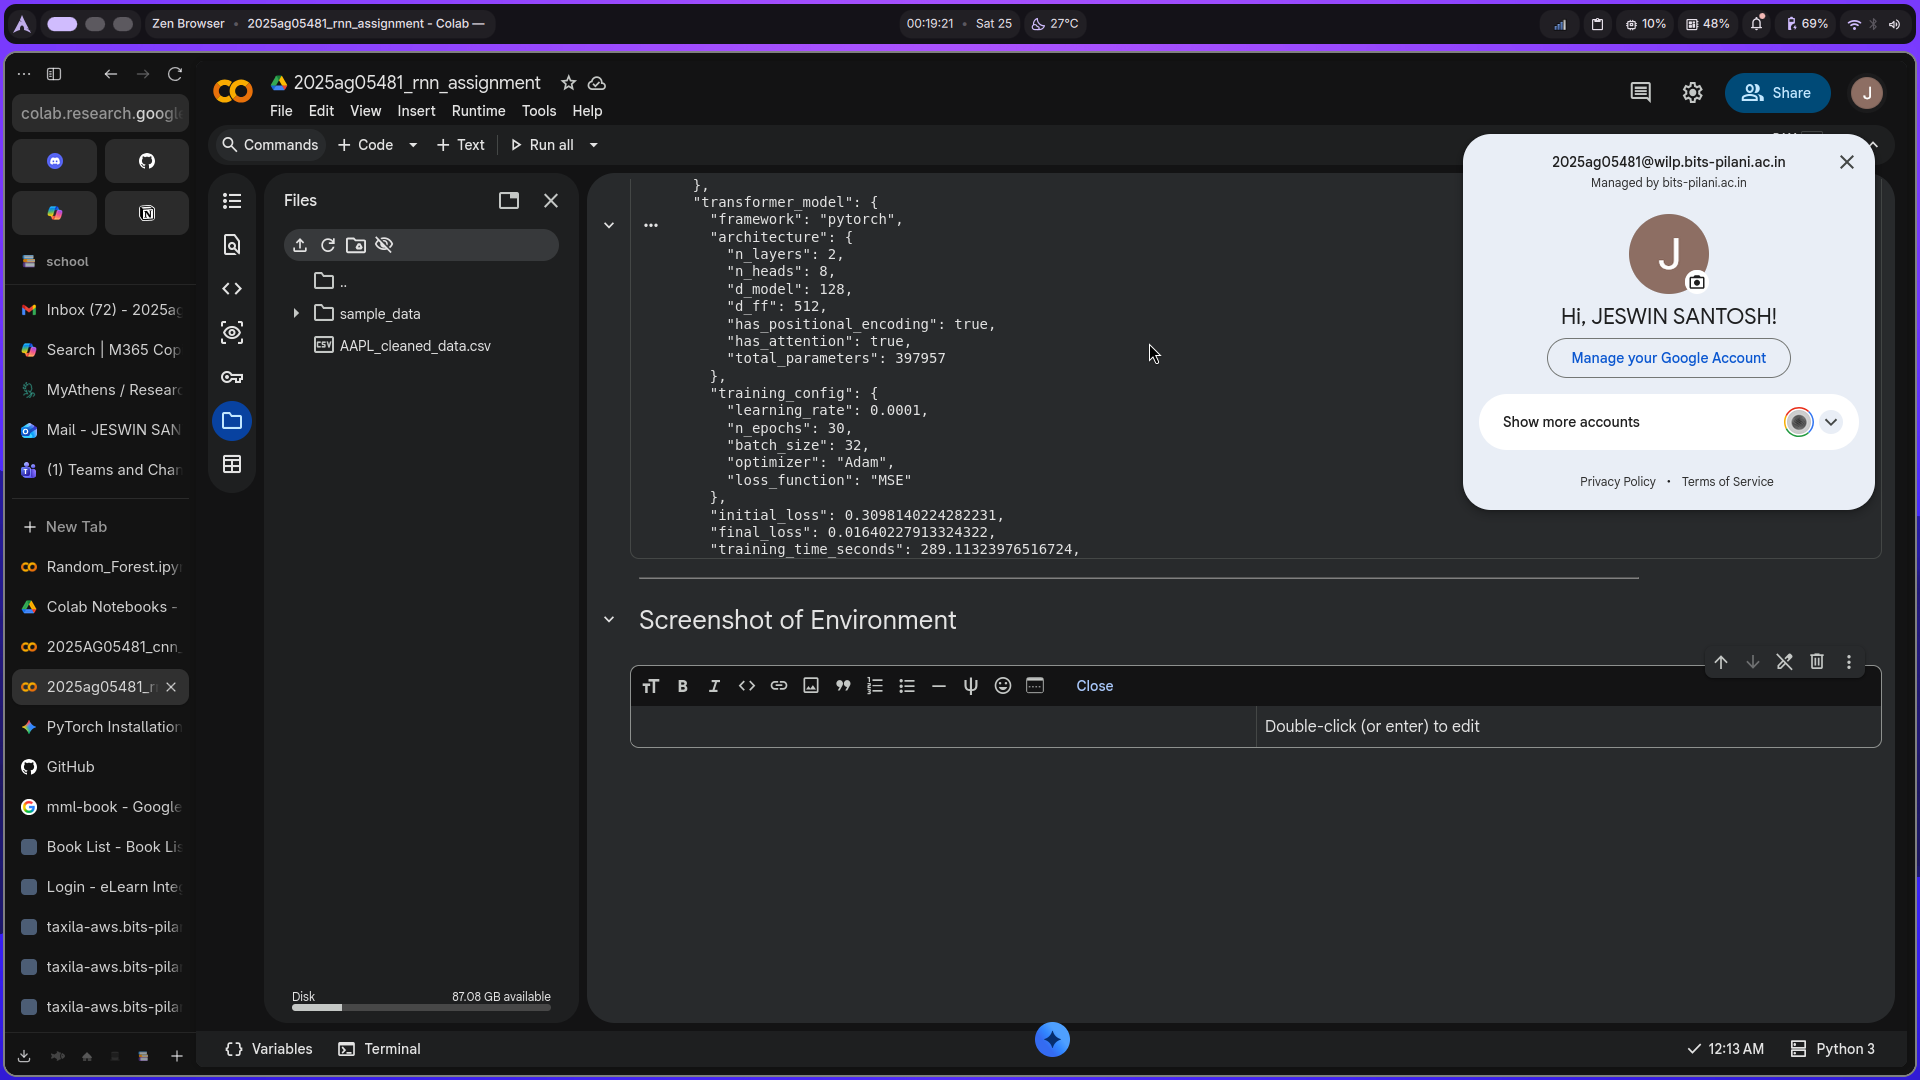